# 原始数据

In [3]:
import pandas as pd
org_data_1 = pd.read_excel("./results/最终数据/final_all_data.xlsx",sheet_name=0)
org_data_2 = pd.read_excel("./results/最终数据/final_all_data.xlsx",sheet_name=1)
org_data_3 = pd.read_excel("./results/最终数据/final_all_data.xlsx",sheet_name=2)

In [4]:
# 训练集数据
edges_1 = org_data_1[['citing','cited']]
# 合并两列数据并去重
unique_node = pd.concat([edges_1['citing'], edges_1['cited']]).drop_duplicates().tolist()
unique_df = pd.DataFrame(unique_node,columns=['citing'])
edges_2 = pd.merge(unique_df,org_data_2,on='citing')

In [5]:
h_edges_1 = edges_1.copy(deep=True)
h_edges_2 = edges_2.copy(deep=True)

edges_3 = pd.DataFrame()
edges_3['citing'] = h_edges_2['cited']
edges_3['cited'] = h_edges_2['citing']

concat_1 = pd.concat([h_edges_2,edges_3])
concat_2 = pd.concat([concat_1,h_edges_1]).reset_index()

citing = concat_2['citing'].tolist()
cited = concat_2['cited'].tolist()
h_edges = []
for p in zip(citing,cited):
    h_edges.append((p[0],p[1]))

In [6]:
g = Graph.TupleList(h_edges,vertex_name_attr='name',edge_attrs=None,directed=True)
vertices_df = pd.DataFrame([{"cited":p[0]['name'], 'Degree':p[1]} for p in zip(g.vs, g.indegree())])
vertices_df

,cited,Degree
0,CN105844614B,1
1,广东工业大学,241
2,CN112214368B,2
3,英业达科技有限公司,28
4,英业达股份有限公司,102
...,...,...
91576,珀迪迈垂克斯公司,1
91577,CN110073404B,3
91578,南坦生物组学有限责任公司,1
91579,CN111366684B,2


In [15]:
degree_sequence = sorted(vertices_df['Degree'], reverse=True)

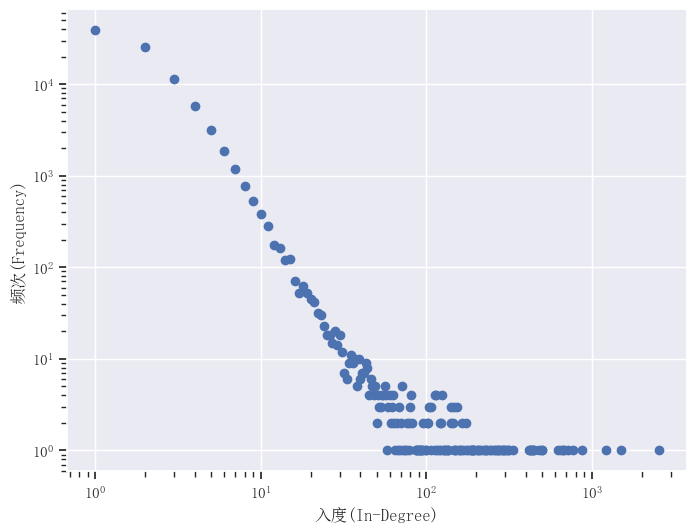

In [18]:
# 计算度数的频率
degree_counts = Counter(degree_sequence)
degree, count = zip(*degree_counts.items())

# 转换为对数坐标
degree = np.array(degree)
count = np.array(count)

plt.figure(figsize=(8, 6))
plt.loglog(degree, count, 'bo')
# plt.title("In-Degree Distribution")
plt.xlabel("入度(In-Degree)")
plt.ylabel("频次(Frequency)")
# 保存图像，确保紧凑显示
plt.savefig('results/无标度网络特征.png', dpi=800, bbox_inches='tight')
plt.show()

In [11]:
average_path_length  = g.average_path_length() #6.733774591920
average_path_length 

7.668221883282183

In [12]:
g.transitivity_avglocal_undirected()  #聚类系数 0.089

0.08914565035004157

In [8]:
g.ecount()

262042

In [9]:
import igraph as ig
import matplotlib.pyplot as plt

# 生成一个 Erdős-Rényi 随机图
n = 91581  # 节点数
m = 262042  # 边数
er_graph = ig.Graph.Erdos_Renyi(n=n, m=m)

In [12]:
average_path_length1  = er_graph.average_path_length() #6.733774591920
average_path_length1 

6.747341912985633

In [13]:
er_graph.transitivity_avglocal_undirected()  #聚类系数 0.089

5.800315232380901e-05

In [ ]:
avg_path_length = nx.average_shortest_path_length(G)
clustering_coeff = average_clustering(G)

# 根据org_data_1中的citing_year获得train_data和test_data数据

In [ ]:
split_year = 2019
# 训练数据集为小于split_year的数据，测试集为大于等于split_year的数据
train_data1 = org_data_1[org_data_1['citing_year'] < split_year]
train_data1 = train_data1.reset_index()

In [ ]:
# 训练集数据
edges_1 = train_data1[['citing','cited']]
# 合并两列数据并去重
unique_node = pd.concat([edges_1['citing'], edges_1['cited']]).drop_duplicates().tolist()
unique_df = pd.DataFrame(unique_node,columns=['citing'])
edges_2 = pd.merge(unique_df,org_data_2,on='citing')

In [ ]:
# 测试数据集
test_data = org_data_1[(org_data_1['citing_year'] >= split_year) & (org_data_1['is_self'] == False)]
test_data = test_data.reset_index()
cited_assignees_dict = {}
for index in test_data.index:
    assignees_split = test_data.iloc[index]['cited_assignees'].split(";")
    for assignee in assignees_split:
        if assignee not in cited_assignees_dict:
            cited_assignees_dict[assignee] = 1
        else:
            cited_assignees_dict[assignee] += 1
test_df = pd.DataFrame.from_dict(cited_assignees_dict, orient='index', columns=['citation_count'])
test_df = test_df.reset_index()
test_df.columns = ['cited','citation_count']
test_df.sort_values(by=['citation_count'],ascending=[False],ignore_index=True,inplace=True)
test_df['rank'] = test_df['citation_count'].rank(axis=0,method='min',ascending=False)

# 算法模块

In [1]:
import csv
import math
import random
import igraph
import datetime
import numpy as np
import pandas as pd
from igraph import *
from sklearn import metrics
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('mode.chained_assignment', None)
import warnings 
warnings.filterwarnings('ignore')

## P_count算法
Tips: P_count算法是指将专利数量越多的专利权人，影响力越大

In [98]:
group_data = edges_2.groupby('cited').count()
group_data = group_data.reset_index()
p_count_merge = pd.merge(test_df,group_data,on='cited')
p_count_merge['P_count_rank'] = p_count_merge['citing'].rank(axis=0,method='min',ascending=False)
p_rank = p_count_merge[['cited','P_count_rank']]
p_rank.columns = ['cited','P']

In [99]:
# p_result = p_rank
# p_result['year'] = split_year

## Citation_Count算法
Tips: Citation_Count算法是指专利权人的引证次数之和

In [100]:
new_df = pd.DataFrame()
new_df['patent'] = edges_1.groupby("cited").count().index
new_df['citation'] = edges_1.groupby('cited').count()['citing'].values
edges_copy = edges_2.copy()
edges_copy.columns = ['patent','order','cited','is_combine','Assignee_type','Assignee_score']
merge_data = pd.merge(edges_copy, new_df, on='patent')
sum_data = merge_data.groupby("cited").sum()
sum_data = sum_data.reset_index()
citation_data = sum_data[['cited','citation']]
cc_merge = pd.merge(test_df,citation_data,on='cited')
cc_merge['citation_count_rank'] = cc_merge['citation'].rank(axis=0,method='min',ascending=False)
cc_rank = cc_merge[['cited','citation_count_rank']]
cc_rank.columns = ['cited','C']

In [101]:
# c_result = cc_rank
# c_result['year'] = split_year

## H-index算法

In [102]:
H_list = dict()
for i in merge_data.groupby('cited'):
    Assignee,sub_data = i[0],i[1]
    sub_data['rank'] = sub_data['citation'].rank(method='min',ascending=False)
    sub_data.sort_values(by=['citation'],ascending=[False],ignore_index=True,inplace=True)
    sub_data = sub_data.reset_index(drop=True)
    
    h = 0
    for index in sub_data.index:
        row_data = sub_data.iloc[index]
        citation, rank = row_data['citation'],row_data['rank']
        if rank + 1 <= citation:
            h += 1
    H_list[Assignee] = h

In [103]:
H_df = pd.DataFrame()
H_df['cited'] = H_list.keys()
H_df['H_index'] = H_list.values()
H_merge = pd.merge(test_df,H_df,on='cited')
H_merge['H_index_rank'] = H_merge['H_index'].rank(axis=0,method='min',ascending=False)
h_rank = H_merge[['cited','H_index_rank']]
h_rank.columns = ['cited','H']
h_rank

,cited,H
0,西安电子科技大学,8.0
1,电子科技大学,23.0
2,华南理工大学,15.0
3,浙江大学,23.0
4,华中科技大学,15.0
...,...,...
2721,宜宾学院,1630.0
2722,上海传英信息技术有限公司,1630.0
2723,恒生电子股份有限公司,1630.0
2724,理光软件研究所（北京）有限公司,1630.0


## G-inde算法

In [104]:
G_list = dict()
for i in merge_data.groupby("cited"):
    Assignee,sub_data = i[0],i[1]
    sum_citation = 0
    sub_data['rank'] =sub_data['citation'].rank(method='min', ascending=False)
    sub_data.sort_values(by=['citation'],ascending=[False],ignore_index=True,inplace=True)
    sub_data = sub_data.reset_index(drop=True)
    g_index = 0
    for index in sub_data.index:
        row_data = sub_data.iloc[index]
        citation, rank = row_data['citation'],row_data['rank']
        sum_citation += citation
        g_square = math.pow(index+1,2)
        if g_square <= sum_citation:
            g_index += 1
    G_list[Assignee] = g_index
G_df = pd.DataFrame()
G_df['cited'] = G_list.keys()
G_df['G_index'] = G_list.values()

G_index_merge = pd.merge(test_df,G_df,on='cited')
G_index_merge['G_index_rank'] = G_index_merge['G_index'].rank(axis=0,method='min',ascending=False)
g_rank = G_index_merge[['cited','G_index_rank']]
g_rank.columns = ['cited','G']
g_rank

,cited,G
0,西安电子科技大学,4.0
1,电子科技大学,10.0
2,华南理工大学,10.0
3,浙江大学,10.0
4,华中科技大学,23.0
...,...,...
2721,宜宾学院,877.0
2722,上海传英信息技术有限公司,877.0
2723,恒生电子股份有限公司,877.0
2724,理光软件研究所（北京）有限公司,877.0


## AN_PRW算法
Tips: AN算法是指根据专利的引证情况，构建专利权人的引证网络，然后采用PageRank算法进行分析专利权人引证网络中的影响力  专利权人引证的结果 （不删除自引）

In [105]:
data = pd.DataFrame()
data['cited_a'] = train_data1['cited_assignees']
data['citing_a'] = train_data1['citing_assignees']

# 作者引用网络关系(不删除自引用的数据)
cited_citing = []
for index in data.index:
    cited_a,citing_a = data.iloc[index]['cited_a'], data.iloc[index]['citing_a']
    for i in cited_a.split(";"):
        for j in citing_a.split(";"):
            cited_citing.append((i,j))

from collections import Counter
cc_dict = dict(Counter(cited_citing))
pd_df = pd.DataFrame.from_dict(cc_dict,orient='index',columns=['count']).reset_index()
edges_a = pd_df['index'].tolist()
edges_w = pd_df['count'].tolist()
assignee_g = Graph.TupleList(edges_a,vertex_name_attr='name',edge_attrs=None,directed=True)
an_prw = pd.DataFrame([{"cited":p[0]['name'], 'AN_PRW':p[1]} for p in zip(assignee_g.vs, assignee_g.pagerank(damping=0.5,weights=edges_w))])
an_prw_merge = pd.merge(test_df,an_prw,on='cited')
an_prw_merge['AN_PRW_rank'] = an_prw_merge['AN_PRW'].rank(axis=0,method='min',ascending=False)
an_prw_rank = an_prw_merge[['cited','AN_PRW_rank']]
an_prw_rank.columns = ['cited','AN_PRW']
an_prw_rank

,cited,AN_PRW
0,西安电子科技大学,8.0
1,电子科技大学,6.0
2,华南理工大学,16.0
3,浙江大学,13.0
4,华中科技大学,23.0
...,...,...
3873,460医药公司,1990.0
3874,深圳博沃智慧科技有限公司,547.0
3875,理光软件研究所（北京）有限公司,2488.0
3876,北京东方计量测试研究所,804.0


## PN_SPR算法
Tips: SPR的方法是PN专利引证网络中，将得到的PR的值加总得到专利权人的影响力，不按专利人数平均

In [106]:
citing = edges_1['citing'].tolist()
cited = edges_1['cited'].tolist()
edges = []
for p in zip(citing,cited):
    edges.append((p[0],p[1]))

g = Graph.TupleList(edges,vertex_name_attr='name',edge_attrs=None,directed=True)
pr_df = pd.DataFrame([{"citing":p[0]['name'], 'PR':p[1]} for p in zip(g.vs, g.pagerank(damping=0.5))])
new_df = edges_2.copy()
pa = new_df.groupby('citing').count()
pa = pa.reset_index()
pa_df = pa[['citing','is_combine']]
pa_df.columns = ['citing','node_count']
pr_merge = pd.merge(new_df, pa_df, on='citing')
pr_merge_1 = pd.merge(pr_merge, pr_df, on='citing')

sum_pr = pr_merge_1.groupby("cited").sum()
sum_pr = sum_pr.reset_index()
pr_data = sum_pr[['cited','PR']]

SPR_merge = pd.merge(test_df,pr_data,on='cited')
SPR_merge['SPR_rank'] = SPR_merge['PR'].rank(axis=0, method='min', ascending=False)
pn_spr_rank = SPR_merge[['cited','SPR_rank']]
pn_spr_rank.columns = ['cited','PN_SPR']
pn_spr_rank

,cited,PN_SPR
0,西安电子科技大学,3.0
1,电子科技大学,6.0
2,华南理工大学,17.0
3,浙江大学,9.0
4,华中科技大学,13.0
...,...,...
3873,460医药公司,3038.0
3874,深圳博沃智慧科技有限公司,3038.0
3875,理光软件研究所（北京）有限公司,2768.0
3876,北京东方计量测试研究所,3038.0


## TAPRW算法

In [107]:
patent_age = org_data_3.copy(deep=True)
patent_age.columns = ['patent','granted_date','age']

In [108]:
citing = edges_1['citing'].tolist()
cited = edges_1['cited'].tolist()
edges = []
for p in zip(citing,cited):
    edges.append((p[0],p[1]))
g = Graph.TupleList(edges,vertex_name_attr='name',edge_attrs=None,directed=True)

# 计算所有专利时间权重的加和
# patent_age['pre_age'] = 1/(patent_age['age']+1)  # 时间函数f(age_i) 采用倒数形式来表示
patent_age['pre_age'] = [math.exp(-0.1* i) for i in patent_age['age'].tolist()] # 采用 指数时间函数

id_mapping = dict((k['name'],k.index) for k in g.vs)
g_vertice = pd.DataFrame.from_dict(id_mapping,orient='index',columns=['id']).reset_index()
g_vertice.columns=['patent','id']

In [109]:
merge_df1 = pd.merge(g_vertice,patent_age,on='patent')
for name, age in zip(merge_df1['id'],merge_df1['pre_age']):
    g.vs.find(name)['age'] = age
sum_age = sum(merge_df1['pre_age'])   #  所有专利时间权重的加和

In [110]:
d,N = 0.5, g.vcount()
w_p = {p.index:1/N for p in g.vs}
for i in range(100000):
    diff = 0 # 初始化偏差
    tmp_dict = {p.index:0 for p in g.vs}
    for node in list(tmp_dict.keys()):
        tmp = 0
        parents_nodes = list(set([i.source for i in g.vs[node].in_edges()]))  # 指向node的父辈节点
        for j in parents_nodes:
            tmp += w_p[j] * g.vs[j]['age']/g.vs[j].outdegree()
        w_pki = (1-d) * g.vs[node]['age'] / sum_age + d*tmp
        tmp_dict[node] = w_pki
    telp = (1-sum(tmp_dict.values())) / N
    w_p_old = w_p.copy()
    for node in w_p.keys():
        w_p[node] = tmp_dict[node] + telp
        diff += abs(w_p[node] - w_p_old[node])
        
    print(i,diff)   
    if diff < 0.00000001:
        break
pr_2 = [{"Patent":p[0]['name'], 'TAPR':p[1]} for p in zip(g.vs, w_p.values())]
vertices_df = pd.DataFrame(pr_2) 
vertices_df.sort_values('TAPR',ascending=False,ignore_index=True,inplace=True)
edges = [(p[0], p[1]) for p in zip(edges_2['citing'], edges_2['cited'])]  # 构建网络的边数据
h_g = Graph.TupleList(edges, vertex_name_attr='name', edge_attrs=None, directed=True)

0 0.18698229730449817
1 0.02394994286317171
2 0.002249675734166502
3 0.0002335688183480402
4 2.114990265650465e-05
5 1.7958458869622062e-06
6 1.6441342602810271e-07
7 1.5348134571030645e-08
8 1.3821167038526445e-09


In [111]:
# 专利权人信息， 专利信息， 包括节点的id和名称
assignees_nodes = []
assignees_names = []
patents_nodes = []
patents_names = []
for i in h_g.vs:
    if 'CN' == i['name'][:2]:
        patents_names.append(i['name'])
        patents_nodes.append(i.index)
    else:
        assignees_nodes.append(i.index)
        assignees_names.append(i['name'])

# 专利列表
patents_df = pd.DataFrame()
patents_df['Patent'] = patents_names
patents_df['nodes'] = patents_nodes
# 专利权人列表
assignees_df = pd.DataFrame()
assignees_df['cited'] = assignees_names
assignees_df['nodes'] = assignees_nodes

In [112]:
patents_merge = pd.merge(vertices_df,patents_df,on='Patent')

N_a, N_p, d = len(assignees_nodes), len(patents_nodes), 0.5
W_p = dict(zip(patents_merge['nodes'],patents_merge['TAPR']))
W_a = {i:1/N_a for i in assignees_nodes}
# 获得专利权人对应的发明专利的所有集合
W_ca = {}
for i in assignees_nodes:    
    W_ca[i] = [j.source for j in h_g.vs[i].all_edges()]
# 获得专利对应的所有专利权人集合
W_cp = {}
for i in patents_nodes:
    W_cp[i] = [j.target for j in h_g.vs[i].all_edges()]
    
W_p0,W_a0 = W_p.copy(), W_a.copy()

for i in range(10000):  
    diff = 0 # 初始化偏差
    W_a_1 = W_a.copy()
    W_p_1 = W_p.copy()
    for key in list(W_a.keys()):
        tmp = 0
        for paper in W_ca[key]:
            tmp += W_p_1[paper]/len(W_cp[paper]) 
        W_a[key] = (1 - d)*W_a0[key] + d * tmp
        
    tel_1 = (1 - sum(W_a.values()))/len(W_a)
    for key in list(W_a.keys()):
        W_a[key] += tel_1
        diff += abs(W_a[key] - W_a_1[key])
    
    for key in list(W_p.keys()):  # 遍历专利数据
        tmp = 0
        for author in W_cp[key]:
            tmp += W_a_1[author]/len(W_ca[author])
        W_p[key] = (1 - d)*W_p0[key] + d * tmp
        
    tel_2 = (1 - sum(W_p.values()))/N_p
    for key in list(W_p.keys()):
        W_p[key] += tel_2
        diff += abs(W_p[key] - W_p_1[key])
    
    print(i, 'diff: ', diff)
    if diff < 0.00000001:
        break


0 diff:  1.2594762105353383
1 diff:  0.6065488360798552
2 diff:  0.295340377846759
3 diff:  0.1455985703446817
4 diff:  0.07210745927346146
5 diff:  0.035842772330731666
6 diff:  0.017860366858538076
7 diff:  0.008906767449025832
8 diff:  0.004443932549806058
9 diff:  0.002218138245341342
10 diff:  0.0011073977236890915
11 diff:  0.0005529503474121181
12 diff:  0.00027612554859349377
13 diff:  0.0001378995921655561
14 diff:  6.88724230522609e-05
15 diff:  3.439978786471343e-05
16 diff:  1.7182497502195906e-05
17 diff:  8.583057293392999e-06
18 diff:  4.28756317166598e-06
19 diff:  2.1418897792718773e-06
20 diff:  1.0700330834382478e-06
21 diff:  5.345804038633647e-07
22 diff:  2.6707913803247257e-07
23 diff:  1.3343929476382116e-07
24 diff:  6.667217346314438e-08
25 diff:  3.3313698303730443e-08
26 diff:  1.6646448016230752e-08
27 diff:  8.319221104137345e-09


In [113]:
# test_df.columns=['cited','citation_count','rank']
taprw = pd.DataFrame.from_dict(W_a,orient='index',columns=['TAPRW']).reset_index()
taprw.columns=['nodes','TAPRW']
result_merge = pd.merge(assignees_df,taprw,on='nodes')
result_merge.sort_values(by=['TAPRW'],ascending=[False],ignore_index=True, inplace=True)

TAPRW_rank = pd.merge(test_df,result_merge,on='cited')
TAPRW_rank['TAPRW_rank'] = TAPRW_rank['TAPRW'].rank(axis=0,method='min',ascending=False)
taprw_rank = TAPRW_rank[['cited','TAPRW_rank']]
taprw_rank.columns = ['cited','TAPRW']
taprw_rank

,cited,TAPRW
0,西安电子科技大学,3.0
1,电子科技大学,5.0
2,华南理工大学,15.0
3,浙江大学,10.0
4,华中科技大学,14.0
...,...,...
3873,460医药公司,3450.0
3874,深圳博沃智慧科技有限公司,2623.0
3875,理光软件研究所（北京）有限公司,3196.0
3876,北京东方计量测试研究所,3199.0


## APR算法

In [114]:
h_edges_1 = edges_1.copy(deep=True)
h_edges_2 = edges_2.copy(deep=True)

edges_3 = pd.DataFrame()
edges_3['citing'] = h_edges_2['cited']
edges_3['cited'] = h_edges_2['citing']

concat_1 = pd.concat([h_edges_2,edges_3])
concat_2 = pd.concat([concat_1,h_edges_1]).reset_index()

citing = concat_2['citing'].tolist()
cited = concat_2['cited'].tolist()
h_edges = []
for p in zip(citing,cited):
    h_edges.append((p[0],p[1]))

In [115]:
g = Graph.TupleList(h_edges,vertex_name_attr='name',edge_attrs=None,directed=True)
vertices_df = pd.DataFrame([{"cited":p[0]['name'], 'PR':p[1]} for p in zip(g.vs, g.pagerank(damping=0.5))])
apr_merge = pd.merge(test_df, vertices_df, on='cited')

apr_merge['APR_rank'] = apr_merge['PR'].rank(axis=0,method='min',ascending=False)
apr_rank = apr_merge[['cited','APR_rank']]
apr_rank.columns = ['cited','APR']
apr_rank

,cited,APR
0,西安电子科技大学,3.0
1,电子科技大学,7.0
2,华南理工大学,19.0
3,浙江大学,8.0
4,华中科技大学,12.0
...,...,...
3873,460医药公司,3254.0
3874,深圳博沃智慧科技有限公司,3500.0
3875,理光软件研究所（北京）有限公司,3398.0
3876,北京东方计量测试研究所,3500.0


## WAPN 算法

In [116]:
assignees_nodes = []  
assignees_names = []
patents_nodes = []
patents_names = []
for i in g.vs:
    if 'CN' == i['name'][:2]:
        patents_names.append(i['name'])
        patents_nodes.append(i.index)
        i['type'] = 'p'
    else:
        assignees_nodes.append(i.index)
        assignees_names.append(i['name'])
        i['type'] = 'a'

# 专利列表
patents_df = pd.DataFrame()
patents_df['Patent'] = patents_names
patents_df['nodes'] = patents_nodes

# 专利权人列表
assignees_df = pd.DataFrame()
assignees_df['cited'] = assignees_names
assignees_df['nodes'] = assignees_nodes

In [117]:
N_a, N_p, d, beta = len(assignees_nodes), len(patents_nodes), 0.5, 0.3
N_all = N_a + N_p

W_p = {i:1/N_all for i in patents_nodes} # 初始化
W_a = {i:1/N_all for i in assignees_nodes}

# 获得专利权人所对应的发明专利的所有集合
W_ca = {}
for i in assignees_nodes:
    W_ca[i] = [j.target for j in g.vs[i].out_edges()]   # 所有专利的数据

# 获得专利对应的参考专利和专利权人数量
W_cb, W_cc, W_cp = {}, {}, {}  # 被引专利, 参考专利 以及  专利权人
for i in patents_nodes:
    W_cb[i] = [j.source for j in g.vs[i].in_edges() if 'CN' in g.vs[j.source]['name'][:2]]
    W_cc[i] = [j.target for j in g.vs[i].out_edges() if 'CN' in g.vs[j.target]['name'][:2]]
    W_cp[i] = [j.target for j in g.vs[i].out_edges() if 'CN' not in g.vs[j.target]['name'][:2]]


W_p0, W_a0 = W_p.copy(), W_a.copy()
for i in range(10000):
    diff = 0
    W_a_1 = W_a.copy()
    W_p_1 = W_p.copy()
   
    for assignee in list(W_a.keys()):
        tmp = 0 
        for patent in W_ca[assignee]:
            tmp += W_p_1[patent]/len(W_cp[patent])
        W_a[assignee] = (1-d)/N_all + d * (1 - beta) * tmp
    # 专利
    for patent in list(W_p.keys()):
        tmp = 0
        for assignee in W_cp[patent]:   # 遍历专利权人的影响
            tmp += W_a_1[assignee] / len(W_ca[assignee])
        
        for reference in W_cb[patent]:     # 遍历专利的父辈节点
            tmp += beta * W_p_1[reference] / len(W_cc[reference])  # 除以父辈节点的输出节点
        
        W_p[patent] = (1-d)/N_all + d * tmp
    
    telep = (1-sum(W_p.values())-sum(W_a.values())) / N_all   # teleport
    for key in list(W_p.keys()):
        W_p[key] += telep
        diff += abs(W_p[key] - W_p_1[key])
    for key in list(W_a.keys()):
        W_a[key] += telep
        diff += abs(W_a[key] - W_a_1[key])

    print(i, 'diff: ', diff)
    if diff < 0.00000001:
        break

0 diff:  0.4879545319266892
1 diff:  0.1785862989083626
2 diff:  0.06681508509193293
3 diff:  0.02535247675533635
4 diff:  0.009716978034311308
5 diff:  0.0037638454126024115
6 diff:  0.0014746576207829577
7 diff:  0.0005825938318942097
8 diff:  0.0002332416607810935
9 diff:  9.379923785116632e-05
10 diff:  3.832928845051236e-05
11 diff:  1.5662551674853044e-05
12 diff:  6.5001444552234e-06
13 diff:  2.6922393774581705e-06
14 diff:  1.1285527893882014e-06
15 diff:  4.717233423997727e-07
16 diff:  1.9937244814078043e-07
17 diff:  8.385289842031318e-08
18 diff:  3.563883052191265e-08
19 diff:  1.5090139608260275e-08
20 diff:  6.427618377185122e-09


In [118]:
apn2 = pd.DataFrame.from_dict(W_a,orient='index',columns=['WAPN']).reset_index()
apn2.columns=['nodes','WAPN']
result_merge1 = pd.merge(assignees_df,apn2,on='nodes')
apr_merge = pd.merge(test_df, result_merge1, on='cited')
apr_merge['WAPN_rank'] = apr_merge['WAPN'].rank(axis=0,method='min',ascending=False)
wapn_rank = apr_merge[['cited','WAPN_rank']]
wapn_rank.columns = ['cited','WAPN']
wapn_rank

,cited,WAPN
0,西安电子科技大学,3.0
1,电子科技大学,5.0
2,华南理工大学,16.0
3,浙江大学,9.0
4,华中科技大学,13.0
...,...,...
3873,460医药公司,3546.0
3874,深圳博沃智慧科技有限公司,2731.0
3875,理光软件研究所（北京）有限公司,2476.0
3876,北京东方计量测试研究所,2731.0


## CWAPN算法

In [119]:
id_mapping = dict((k['name'],k.index) for k in g.vs)
g_vertice = pd.DataFrame.from_dict(id_mapping,orient='index',columns=['id']).reset_index()
g_vertice.columns=['patent','id']
merge_df1 = pd.merge(g_vertice,patent_age,on='patent')
for name, age in zip(merge_df1['id'],merge_df1['pre_age']):
    g.vs.find(name)['age'] = age

In [120]:
sum_age = sum(merge_df1['pre_age'])   #  所有专利时间权重的加和
assignees_nodes = []  
assignees_names = []
patents_nodes = []
patents_names = []
for i in g.vs:
    if 'CN' == i['name'][:2]:
        patents_names.append(i['name'])
        patents_nodes.append(i.index)
        i['type'] = 'p'
    else:
        assignees_nodes.append(i.index)
        assignees_names.append(i['name'])
        i['type'] = 'a'

# 专利列表
patents_df = pd.DataFrame()
patents_df['Patent'] = patents_names
patents_df['nodes'] = patents_nodes

# 专利权人列表
assignees_df = pd.DataFrame()
assignees_df['cited'] = assignees_names
assignees_df['nodes'] = assignees_nodes

In [121]:
h_edges_2['order_score'] = round(1/h_edges_2['order'],3)   # 获得专利权人所在的顺序

new_df =pd.DataFrame() # 构建新的DataFrame
new_df['citing'] = h_edges_2.groupby("citing").sum().reset_index()['citing']  # 专利名称
new_df['sum_order'] = h_edges_2.groupby("citing").sum().reset_index()['order_score']  # 总的排名得分
new_merge_df = pd.merge(h_edges_2,new_df,on='citing')

In [122]:
name_index = []  # 从图网络中获得专利的名称及其索引值
for i in g.vs:
    name_index.append({"citing":i['name'],"citing_index":i.index})
name_index_df = pd.DataFrame(name_index)
name_merge1 = pd.merge(new_merge_df,name_index_df,on='citing')
# 从图网络中获得专利权人的名称及其索引
name_index_2 = []
for i in g.vs:
    name_index_2.append({"cited":i['name'],"cited_index":i.index})
name_index_df2 = pd.DataFrame(name_index_2)
name_merge2 = pd.merge(name_merge1,name_index_df2,on='cited')

name_merge2['order_value'] = round(name_merge2['order_score'] / name_merge2['sum_order'],2) # 获得专利权人所在专利的顺序获得的信誉分配值

In [123]:
# 构建一个字典，用于存放专利权人：专利：信誉分配值， 主要用于后面进行查找和分配信誉分配值
order_dict = {}
for index in name_merge2.index:
    row = name_merge2.iloc[index]
    row_key = row['cited_index']
    row_sub_key = row['citing_index']
    row_value = row['order_value']
    if row_key not in order_dict:
        order_dict[row_key] = {}
    order_dict[row_key][row_sub_key] = row_value

In [124]:
# 获得专利权人的类型得分，将其认为不同类型的专利权人其创新程度值的贡献不一样
assignee_df = pd.DataFrame()
assignee_df['cited'] = h_edges_2['cited']
assignee_df['Assignee_score'] = h_edges_2['Assignee_score']
assignee_df = assignee_df.drop_duplicates()  # 删除重复项
sum_score = sum(assignee_df['Assignee_score'])  # 获得所有专利权人的类型得分之和
# 将获得的专利权人类型得分写入网络图中
for name, count in zip(assignee_df['cited'], assignee_df['Assignee_score']):
    g.vs.find(name)['Assignee_score'] = count

In [125]:
# 先初始化各参数，并进行遍历迭代
N_a, N_p, d, beta = len(assignees_nodes), len(patents_nodes), 0.7, 0.4  # 包括阻尼系数，包括权重系数  需要修改

W_p = {i:1/N_p for i in patents_nodes} # 初始化专利及其得分
W_a = {i:1/N_a for i in assignees_nodes}  # 初始化专利权人及其得分

# 获得专利权人所对应的发明专利的所有集合
W_ca = {}
for i in assignees_nodes:
    W_ca[i] = [j.target for j in g.vs[i].out_edges()]   # 所有专利的数据

# 获得专利对应的参考专利和专利权人数量
W_cb, W_cc, W_cp = {}, {}, {}  # 被引专利, 参考专利 以及  专利权人
for i in patents_nodes:
    W_cb[i] = [j.source for j in g.vs[i].in_edges() if 'CN' in g.vs[j.source]['name'][:2]]
    W_cc[i] = [j.target for j in g.vs[i].out_edges() if 'CN' in g.vs[j.target]['name'][:2]]
    W_cp[i] = [j.target for j in g.vs[i].out_edges() if 'CN' not in g.vs[j.target]['name'][:2]]

# 初始化
W_p0, W_a0 = W_p.copy(), W_a.copy()
for i in range(10000):
    diff = 0
    W_a_1 = W_a.copy()
    W_p_1 = W_p.copy()
    # 遍历专利权人节点
    for assignee in list(W_a.keys()):
        tmp = 0 
        for patent in W_ca[assignee]:
            # 将专利权人所在专利的信誉分配度赋值给对应的专利，说明排名越靠前的专利权人其重要程度越大
            tmp += W_p_1[patent] * order_dict[assignee][patent]         # /len(W_cp[patent])
        
        assignee_value = g.vs[assignee]['Assignee_score']   # 专利权人类型得分，我们设定为高校和科研机构为3分，企业为2分，个人为1分
        W_a[assignee] = (1-d)  * assignee_value / sum_score  + d * (1 - beta) * tmp  # * W_a0[assignee]
    
    # 遍历专利节点
    for patent in list(W_p.keys()):
        tmp = 0
        for assignee in W_cp[patent]:   # 遍历专利权人的影响
            tmp += W_a_1[assignee]  / len(W_ca[assignee])  # 专利权人的影响力除以其所写论文的数量  W_ca代表assignee所写的论文总数量
        
        for reference in W_cb[patent]:     # 遍历专利的父辈节点
            tmp += beta * g.vs[reference]['age']  *   W_p_1[reference] / len(W_cc[reference])  # 除以父辈节点的输出节点
        
        W_p[patent] = (1-d) * g.vs[patent]['age'] / sum_age  + d * tmp  # 更新专利的得分，包含专利的年龄占比，以及其从网络中获得的得分    
    
    telep_1 = (1-sum(W_p.values())) / N_p   # teleport
    for key in list(W_p.keys()):
        W_p[key] += telep_1
        diff += abs(W_p[key] - W_p_1[key])
    
    telep_2 = (1-sum(W_a.values()))/ N_a
    for key in list(W_a.keys()):
        W_a[key] += telep_2
        diff += abs(W_a[key] - W_a_1[key])

    print(i, 'diff: ', diff)
    if diff < 0.00000001:
        break

0 diff:  1.410566716603303
1 diff:  0.7067886877873459
2 diff:  0.37713137451531803
3 diff:  0.19543047727179766
4 diff:  0.1069664278406968
5 diff:  0.05644570111830346
6 diff:  0.03114699234739198
7 diff:  0.016619907339258926
8 diff:  0.009207566369277422
9 diff:  0.004954355809714316
10 diff:  0.0027522556580972237
11 diff:  0.0014908508165845627
12 diff:  0.0008286161538333706
13 diff:  0.0004518320422694015
14 diff:  0.000250999209760481
15 diff:  0.00013769240609437796
16 diff:  7.635334019492248e-05
17 diff:  4.217641197017188e-05
18 diff:  2.338223640333607e-05
19 diff:  1.2986012120602584e-05
20 diff:  7.203096143637557e-06
21 diff:  4.0111915810626335e-06
22 diff:  2.22381482495072e-06
23 diff:  1.2409218262528927e-06
24 diff:  6.878368239216107e-07
25 diff:  3.8445816539488173e-07
26 diff:  2.1305958724690477e-07
27 diff:  1.1924065959797208e-07
28 diff:  6.608184583502815e-08
29 diff:  3.7042716057825005e-08
30 diff:  2.052939359235286e-08
31 diff:  1.1521365015488965e-08


In [126]:
cwapn = pd.DataFrame.from_dict(W_a,orient='index',columns=['CWAPN']).reset_index()
cwapn.columns=['nodes','CWAPN']
result_merge3 = pd.merge(assignees_df,cwapn,on='nodes')
tawapr_merge = pd.merge(test_df, result_merge3, on='cited')
tawapr_merge['CWAPN_rank'] = tawapr_merge['CWAPN'].rank(axis=0,method='min',ascending=False)
cwapn_rank = tawapr_merge[['cited','CWAPN_rank']]
cwapn_rank.columns = ['cited','CWAPN']
cwapn_rank

,cited,CWAPN
0,西安电子科技大学,3.0
1,电子科技大学,5.0
2,华南理工大学,14.0
3,浙江大学,10.0
4,华中科技大学,15.0
...,...,...
3873,460医药公司,3410.0
3874,深圳博沃智慧科技有限公司,2690.0
3875,理光软件研究所（北京）有限公司,2514.0
3876,北京东方计量测试研究所,1265.0


In [127]:
# cwapn_result = cwapn_rank
# cwapn_result['year'] = split_year

# 合并得到的排名数据

In [128]:
# merge_1
merge_1 = pd.merge(test_df,p_rank,on='cited',how='left')
merge_1['P'].fillna(merge_1['P'].notna().sum() + 1, inplace=True) 
# merge_2
merge_2 = pd.merge(merge_1, cc_rank, on='cited', how='left')
merge_2['C'].fillna(merge_2['C'].notna().sum() + 1, inplace=True)
# merge_3
merge_3 = pd.merge(merge_2, h_rank, on='cited', how='left')
merge_3['H'].fillna(merge_3['H'].notna().sum() + 1, inplace=True)
# merge_4
merge_4 = pd.merge(merge_3, g_rank, on='cited', how='left')
merge_4['G'].fillna(merge_4['G'].notna().sum() + 1, inplace=True)
# merge_5
merge_5 = pd.merge(merge_4, an_prw_rank, on='cited', how='left')
merge_5['AN_PRW'].fillna(merge_5['AN_PRW'].notna().sum() + 1, inplace=True)
# merge_6
merge_6 = pd.merge(merge_5, pn_spr_rank, on='cited', how='left')
merge_6['PN_SPR'].fillna(merge_6['PN_SPR'].notna().sum() + 1, inplace=True)
# merge_7
merge_7 = pd.merge(merge_6, taprw_rank, on='cited', how='left')
merge_7['TAPRW'].fillna(merge_7['TAPRW'].notna().sum() + 1, inplace=True)
# merge_8
merge_8 = pd.merge(merge_7, apr_rank, on='cited', how='left')
merge_8['APR'].fillna(merge_8['APR'].notna().sum() + 1, inplace=True)
# merge_9
merge_9 = pd.merge(merge_8, wapn_rank, on='cited', how='left')
merge_9['WAPN'].fillna(merge_9['WAPN'].notna().sum() + 1, inplace=True)
# merge_10
merge_10 = pd.merge(merge_9, cwapn_rank, on='cited', how='left')
merge_10['CWAPN'].fillna(merge_10['CWAPN'].notna().sum() + 1, inplace=True)


In [129]:
result_data= merge_10.copy(deep=True)  # 获得最终的结果

In [130]:
result_data

,cited,citation_count,rank,P,C,H,G,AN_PRW,PN_SPR,TAPRW,APR,WAPN,CWAPN
0,西安电子科技大学,1012,1.0,3.0,3.0,8.0,4.0,8.0,3.0,3.0,3.0,3.0,3.0
1,电子科技大学,824,2.0,6.0,7.0,23.0,10.0,6.0,6.0,5.0,7.0,5.0,5.0
2,华南理工大学,707,3.0,18.0,12.0,15.0,10.0,16.0,17.0,15.0,19.0,16.0,14.0
3,浙江大学,645,4.0,10.0,10.0,23.0,10.0,13.0,9.0,10.0,8.0,9.0,10.0
4,华中科技大学,632,5.0,14.0,13.0,15.0,23.0,23.0,13.0,14.0,12.0,13.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,北京天华星航科技有限公司,1,3980.0,3879.0,2727.0,2727.0,2727.0,3879.0,3879.0,3879.0,3879.0,3879.0,3879.0
7367,中国光大银行股份有限公司信用卡中心,1,3980.0,3879.0,2727.0,2727.0,2727.0,3879.0,3879.0,3879.0,3879.0,3879.0,3879.0
7368,广州比格威医疗科技有限公司,1,3980.0,3879.0,2727.0,2727.0,2727.0,3879.0,3879.0,3879.0,3879.0,3879.0,3879.0
7369,北京东方计量测试研究所,1,3980.0,2130.0,2727.0,2727.0,2727.0,804.0,3038.0,3199.0,3500.0,2731.0,1265.0


In [131]:
Number = 500
N_list = range(1,Number+1)
for column in result_data.columns[3:]:
    ndcg_list,acc_list = 0,0
    for top_N in N_list:
        sub_data = result_data.iloc[:top_N][column].values.tolist()
        in_data = [i for i in sub_data if int(i) <= top_N]
        tmp,sum_tmp = 0,0
        for i in range(len(sub_data)):
            rel_i = 0
            if sub_data[i]!='-' and int(sub_data[i]) <= top_N:
                rel_i = 1
            tmp += (2**rel_i - 1) / (math.log2(i+2))
            sum_tmp += (2-1)/(math.log2(i+2))
        ndcg = round(tmp/sum_tmp, 3)
        ndcg_list += ndcg
        acc_list += round(len(in_data)/top_N,3)
    #     print("Top N count: ", top_N, ', 总数量： ',len(in_data), ',Average：', round(len(in_data)/top_N,3), ", NDCG@K score: ", ndcg)
    print("column: ",column,', average accuracy:',round(acc_list/Number*100,2),', average ndcg:',round(ndcg_list/Number*100,2))

column:  P , average accuracy: 64.24 , average ndcg: 70.77
column:  C , average accuracy: 60.97 , average ndcg: 67.67
column:  H , average accuracy: 58.44 , average ndcg: 64.89
column:  G , average accuracy: 64.56 , average ndcg: 70.39
column:  AN_PRW , average accuracy: 56.67 , average ndcg: 64.12
column:  PN_SPR , average accuracy: 63.22 , average ndcg: 69.86
column:  TAPRW , average accuracy: 65.32 , average ndcg: 71.69
column:  APR , average accuracy: 60.49 , average ndcg: 67.47
column:  WAPN , average accuracy: 64.15 , average ndcg: 70.68
column:  CWAPN , average accuracy: 66.97 , average ndcg: 73.05


## 动态数据汇总
Tips: split_year = 2019
|年份|指标|P|C|H|G|AN_PRW|PN_SPR|TAPRW|APR|WAPN|CWAPN|
|---|---|---|---|---|---|---|---|---|---|---|---|
|全部|ACC@500|63.70|60.82|62.46|62.44|58.81|63.58|65.99|60.43|63.87|68.00|
|全部|NDCG@500|70.30|67.65|68.15|68.38|65.95|70.13|72.19|67.41|70.41|73.85|
|2019|ACC@500|63.48|60.68|62.31|62.31|58.72|62.66|65.75|60.20|63.62|67.75|
|2019|NDCG@500|70.11|67.53|67.99|68.28|65.87|69.37|71.99|67.21|70.20|73.65|
|2018|ACC@500|63.68|60.50|59.14|64.17|56.69|62.60|65.02|60.15|63.64|66.81|
|2018|NDCG@500|70.32|67.27|65.46|70.01|64.12|69.32|71.44|67.18|70.24|72.91|
|2017|ACC@500|63.39|59.76|61.89|63.99|57.77|62.17|64.41|60.09|63.05|65.55|
|2017|NDCG@500|69.99|66.54|67.93|69.76|65.03|68.86|70.8|66.99|69.6|71.66|
|2016|ACC@500|63.20|58.35|59.75|60.75|56.84|61.77|63.25|59.23|62.14|64.64|
|2016|NDCG@500|69.73|65.18|65.89|66.7|64.11|68.44|69.72|66.07|68.7|70.81|
|2015|ACC@500|63.25|58.53|62.45|63.06|56.66|61.71|62.53|58.74|61.82|64.42|
|2015|NDCG@500|69.42|65.00|67.97|68.71|63.97|68.01|68.88|65.33|68.14|70.41|
|2014|ACC@500|63.28|56.77|59.93|63.25|55.05|61.42|62.08|58.62|61.8|63.97|
|2014|NDCG@500|69.27|63.32|65.78|68.63|62.24|67.65|68.27|65.21|68.03|69.79|
|2013|ACC@500|63.83|57.51|58.63|66.82|54.59|61.62|61.42|58.35|61.26|63.3|
|2013|NDCG@500|69.73|63.96|64.7|71.89|61.69|67.75|67.68|64.87|67.5|69.11|
|2012|ACC@500|65.43|57.55|59.08|68.97|54.3|62.12|61.99|58.1|62.09|63.06|
|2012|NDCG@500|71.39|64.21|65.08|73.95|61.82|68.49|68.39|64.96|64.46|69.33|

In [ ]:
# column:  P , average accuracy: 63.702 , average ndcg: 70.295
# column:  C , average accuracy: 60.82 , average ndcg: 67.651
# column:  H , average accuracy: 62.459 , average ndcg: 68.145
# column:  G , average accuracy: 62.437 , average ndcg: 68.378
# column:  AN_PRW , average accuracy: 58.811 , average ndcg: 65.949
# column:  PN_SPR , average accuracy: 63.575 , average ndcg: 70.134
# column:  TAPRW , average accuracy: 65.988 , average ndcg: 72.189
# column:  APR , average accuracy: 60.432 , average ndcg: 67.407
# column:  WAPN , average accuracy: 63.87 , average ndcg: 70.407
# column:  CWAPN , average accuracy: 67.999 , average ndcg: 73.85

# 准确率

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from matplotlib import rcParams
config = {
    'font.family':'serif',
    'font.size':14,
    'mathtext.fontset':'stix',
    'font.serif':['SimSun']
}
rcParams.update(config)

a_style = sns.axes_style({'figure.facecolor': 'None',
 'axes.labelcolor': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'axes.axisbelow': True,
 'grid.linestyle': '-',
 'text.color': '.15',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'line.solid_capstyle': 'projecting',
 'line.linewidth':'400',
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'xtick.top': False,
 'ytick.right': False,
 'axes.grid': True,
 'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'grid.color': 'white',
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True,
 'xtick.bottom': True,
 'ytick.left': True})

sns.set(style=a_style)

config = {
    'font.family':'serif',
    'font.size':15,
    'mathtext.fontset':'stix',
    'font.serif':['SimSun']
}
rcParams.update(config)


In [ ]:
def cal(data, top_k,key):
    acc_k = 0
    for j in data[key].values[:top_k]:
        if j!= '-' and j <= top_k:
            acc_k += 1
    return acc_k

keys = ['P', 'C', 'H', 'G', 'AN_PRW', 'PN_SPR', 'TAPRW','APR', 'WAPN', 'CWAPN']
acc_p,acc_c,acc_h,acc_g,acc_anprw,acc_pnspr,acc_taprw,acc_apr,acc_wapn,acc_fwapn = [],[],[],[],[],[],[],[],[],[]
for i in range(1,521,20):
    top_k = i
    for key in keys:
        acc_k = cal(result_data, top_k,key)
        if key == 'P':
            acc_p.append(round(acc_k/top_k,2)*100)
        if key == 'C':
            acc_c.append(round(acc_k/top_k,2)*100)
        if key == 'H':
            acc_h.append(round(acc_k/top_k,2)*100)
        if key == 'G':
            acc_g.append(round(acc_k/top_k,2)*100)
        if key == 'AN_PRW':
            acc_anprw.append(round(acc_k/top_k,2)*100)
        if key == 'PN_SPR':
            acc_pnspr.append(round(acc_k/top_k,2)*100)
        if key == 'TAPRW':
            acc_taprw.append(round(acc_k/top_k,2)*100)
        if key == 'APR':
            acc_apr.append(round(acc_k/top_k,2)*100)
        if key == 'WAPN':
            acc_wapn.append(round(acc_k/top_k,2)*100)
        if key == 'CWAPN':
            acc_fwapn.append(round(acc_k/top_k,2)*100)
    

In [ ]:
plt.figure(figsize = [10,6],dpi=800)
x = range(1,521,20)
color_list = ['#9932CC','#DEB887','#00FFFF','#7FFFD4','#F0FFFF','#FF8C00','#FAEBD7','#DC143C','#7FFF00','#B8860B']

plt.plot(x,acc_p, 'o--',label='P',markersize=2)
plt.plot(x,acc_c, 's--', label='C',markersize=5)
plt.plot(x,acc_h, 'x:',label='H',markersize=4)
plt.plot(x,acc_g, 'o:',label='G',markersize=2)
plt.plot(x,acc_anprw,'-.', label='AN_PRW',markersize=3)
plt.plot(x,acc_pnspr,'s-.', label='PN_SPR',markersize=3)
plt.plot(x,acc_taprw, '.--',label='TAPRW',markersize=4)
plt.plot(x,acc_apr,  label='APR',markersize=2)
plt.plot(x,acc_wapn, 'x-',label='WAPN',markersize=6)
plt.plot(x,acc_fwapn,'o-',label='CWAPN',markersize=5)


# plt.plot(small_df['cited year gap'],small_df['count'],'o--',color='red', label='小于零')
# plt.plot(big_df['cited year gap'],big_df['count'],'o-',label='大于零')
plt.ticklabel_format( axis='y',style='plain')   # 科学计数法
plt.xlabel('Top $k$',fontsize=13) # 放大横轴名称
plt.ylabel('准确率（%）',fontsize=13) # 放大纵轴名称
plt.legend()
plt.savefig('./results/figures/Top500准确率分布_2012.png',bbox_inches='tight')

# 前100名的箱线图

In [ ]:
new_data = result_data[['P', 'C', 'H', 'G', 'AN_PRW', 'PN_SPR', 'TAPRW','APR', 'WAPN', 'CWAPN']].iloc[:100]
# 使用replace()函数将值为"-"替换为NaN
# new_data.replace('-', 0, inplace=True)

color_list = ['#9932CC','#DEB887','#00FFFF','#7FFFD4','#F0FFFF','#FF8C00','#FAEBD7','#DC143C','#7FFF00','#B8860B']

plt.figure(figsize=(10,6),dpi=800)
plt.grid(True)
bp = plt.boxplot(new_data.values, labels = new_data.columns, sym='g+',patch_artist=True)  # , ,  showmeans=True
# color_list = ['black','blue','red','yellow','orange','green','black','white','purple','green']
[bp['boxes'][i].set(facecolor=color_list[i], alpha=0.7) for i in range(10)]
plt.ylabel('专利权人排名',fontsize=13) # 放大纵轴名称
plt.savefig('./results/figures/Top100箱线图分布_2012.png',bbox_inches='tight')

# PR曲线

In [ ]:
true_list = []
for index in result_data.index:
    true_rank = result_data.iloc[index]['rank']
    if true_rank <= 300:
        true_list.append(1.0)
    else:
        true_list.append(0.0)        
result_data['true_label'] = true_list

config = {
    'font.family':'serif',
    'font.size':15,
    'mathtext.fontset':'stix',
    'font.serif':['SimSun']
}
rcParams.update(config)

from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize = [10,6],dpi=800)

for column in result_data.columns[3:-1]:
    new_data = result_data[['true_label',column]]
    new_data.replace('-', 1, inplace=True)
    new_data.sort_values(by=[column],ascending=[True],ignore_index=True,inplace=True)
    
    sensitivity_list, specificity_list = [],[]
    for threshold in range(1,len(new_data),15):  # len(new_data)
        true_label = new_data['true_label'].values
        pre_label = []
        for i in new_data[column].values:
            if i<= threshold:
                pre_label.append(1)
            else:
                pre_label.append(0)
        tn, fp,fn, tp = metrics.confusion_matrix(true_label, pre_label).ravel()
        fpr,tpr = fp/(fp+tn), tp/(tp+fn)   # tp /(tp+fn)
        precision = tp/(tp+fp)  # 准确率
        specificity_list.append(precision)  # 修改
        sensitivity_list.append(tpr)
    
    new_df = pd.DataFrame()
    new_df['specificity'] = specificity_list
    new_df['sensitivity'] = sensitivity_list
    if column == 'P':
        plt.plot(sensitivity_list,specificity_list,'o--',label=column,markersize=2)
    if column == 'C':
        plt.plot(sensitivity_list,specificity_list,'s--',label=column,markersize=5)
    if column=='TAPRW':
        plt.plot(sensitivity_list,specificity_list,'.--',label=column,markersize=4)
    if column == 'H':
        plt.plot(sensitivity_list,specificity_list,'x:',label=column,markersize=4)
    if column== 'G':
        plt.plot(sensitivity_list,specificity_list,'o:',label=column,markersize=2)
        
    if column == 'AN_PRW':
        plt.plot(sensitivity_list,specificity_list,'-.',label=column,markersize=3)
    if column == 'PN_SPR':
        plt.plot(sensitivity_list,specificity_list,'s-.',label=column,markersize=3)
    if column == 'APR':
        plt.plot(sensitivity_list,specificity_list,label=column,markersize=2)
    if column == 'WAPN':
        plt.plot(sensitivity_list,specificity_list,'x-',label=column,markersize=6)
    if column == 'CWAPN':
        plt.plot(sensitivity_list,specificity_list,'o-',label=column,markersize=5)
    
    auc_score = metrics.auc( new_df['sensitivity'], new_df['specificity'])
    print("Metric name: ", column, ", AUC score: ", round(auc_score*100,2))

plt.xlabel('召回率（Recall）',fontsize=13) # 放大横轴名称
plt.ylabel('精确率（Precision）',fontsize=13) # 放大纵轴名称
plt.legend()
plt.savefig('./results/figures/PR_AUC_2012.png',bbox_inches='tight')

|年份|指标|P|C|H|G|AN_PRW|PN_SPR|TAPRW|APR|WAPN|CWAPN|
|---|---|---|---|---|---|---|---|---|---|---|---|
|全部|AUC@500|66.10|62.96|54.89|56.94|62.09|66.26|69.29|62.71|66.49|71.31|
|2019|AUC@500|66.96|63.84|54.37|57.95|61.74|67.02|69.77|63.38|67.57|71.52|
|2018|AUC@500|65.94|60.84|51.76|55.36|59.20|65.81|68.48|62.62|66.39|70.74|
|2017|AUC@500|65.92|60.57|50.01|53.90|59.12|65.13|67.08|62.08|65.53|68.30|
|2016|AUC@500|66.12|58.89|46.15|51.78|57.22|64.96|65.81|60.80|64.20|67.21|
|2015|AUC@500|64.75|58.17|49.23|52.26|55.06|64.28|64.32|59.90|63.28|66.32|
|2014|AUC@500|62.59|54.66|46.34|49.35|53.58|61.68|62.51|58.06|61.85|64.62|
|2013|AUC@500|63.04|53.88|44.14|50.00|51.93|62.26|62.5|57.83|62.27|64.07|
|2012|AUC@500|64.29|54.46|45.42|50.59|52.92|63.39|63.62|58.7|63.22|65.23|

In [ ]:
Metric name:  P , AUC score:  0.6696220511341899
Metric name:  C , AUC score:  0.6383577077449039
Metric name:  H , AUC score:  0.5437067906631156
Metric name:  G , AUC score:  0.57952803381231
Metric name:  AN_PRW , AUC score:  0.617423666407122
Metric name:  PN_SPR , AUC score:  0.6701566305466582
Metric name:  TAPRW , AUC score:  0.6976949979413611
Metric name:  APR , AUC score:  0.6337673136791084
Metric name:  WAPN , AUC score:  0.6756486740443968
Metric name:  CWAPN , AUC score:  0.7151604666109714

# 动态网络构建数据

In [94]:
# 训练集为10年度，测试集为随后五年度
split_year = 2018
# 训练数据集为小于split_year的数据，测试集为大于等于split_year的数据
train_data1 = org_data_1[(org_data_1['citing_year'] < split_year) & (org_data_1['citing_year'] >= split_year-8)]
train_data1 = train_data1.reset_index()
train_data1

,index,citing,citing_assignees,cited,cited_assignees,citing_year,is_self
0,0,CN105844614B,广东工业大学,CN105260710B,北京石油化工学院,2016,False
1,3,CN104608125B,精工爱普生株式会社,CN105234938B,精工爱普生株式会社,2013,True
2,4,CN106239505B,广东电网有限责任公司电力科学研究院,CN105234938B,精工爱普生株式会社,2016,False
3,5,CN108972536B,西门子（中国）有限公司,CN105234938B,精工爱普生株式会社,2017,False
4,6,CN109154276B,维斯塔斯风力系统集团公司,CN105257475B,北京科诺伟业科技股份有限公司;科诺伟业风能设备（北京）有限公司,2016,False
...,...,...,...,...,...,...,...
38209,98154,CN107103307B,京东方科技集团股份有限公司,CN104182727B,渭南印象认知技术有限公司,2017,False
38210,98155,CN107657240B,上海天马微电子有限公司,CN104182727B,渭南印象认知技术有限公司,2017,False
38211,98168,CN107688783B,京东方科技集团股份有限公司,CN110234400B,医科达有限公司,2017,False
38212,98182,CN108399379B,北京市商汤科技开发有限公司,CN107735795B,北京市商汤科技开发有限公司,2017,True


In [95]:
# 训练集数据
edges_1 = train_data1[['citing','cited']]
# 合并两列数据并去重
unique_node = pd.concat([edges_1['citing'], edges_1['cited']]).drop_duplicates().tolist()
unique_df = pd.DataFrame(unique_node,columns=['citing'])
edges_2 = pd.merge(unique_df,org_data_2,on='citing')

In [96]:
# 测试数据集
test_data = org_data_1[(org_data_1['citing_year'] >= split_year) & (org_data_1['citing_year'] < split_year + 5) & (org_data_1['is_self'] == False)]

test_data = test_data.reset_index()
cited_assignees_dict = {}
for index in test_data.index:
    assignees_split = test_data.iloc[index]['cited_assignees'].split(";")
    for assignee in assignees_split:
        if assignee not in cited_assignees_dict:
            cited_assignees_dict[assignee] = 1
        else:
            cited_assignees_dict[assignee] += 1
test_df = pd.DataFrame.from_dict(cited_assignees_dict, orient='index', columns=['citation_count'])
test_df = test_df.reset_index()
test_df.columns = ['cited','citation_count']
test_df.sort_values(by=['citation_count'],ascending=[False],ignore_index=True,inplace=True)
test_df['rank'] = test_df['citation_count'].rank(axis=0,method='min',ascending=False)

In [97]:
test_df

,cited,citation_count,rank
0,西安电子科技大学,1012,1.0
1,电子科技大学,824,2.0
2,华南理工大学,707,3.0
3,浙江大学,645,4.0
4,华中科技大学,632,5.0
...,...,...,...
7366,北京天华星航科技有限公司,1,3980.0
7367,中国光大银行股份有限公司信用卡中心,1,3980.0
7368,广州比格威医疗科技有限公司,1,3980.0
7369,北京东方计量测试研究所,1,3980.0


In [ ]:
cwapn_save_df = pd.DataFrame()

In [ ]:
cwapn_save_df = pd.concat([cwapn_save_df,cwapn_result])
cwapn_save_df

In [ ]:
cwapn_save_df.to_excel("./results/最终数据/CWAPN_2013_2023结果.xlsx",index=None)

In [ ]:
p_save_df = pd.DataFrame()
c_save_df = pd.DataFrame()

# 遍历data

In [ ]:
p_save_df = pd.concat([p_save_df,p_result])
p_save_df

In [ ]:
c_save_df = pd.concat([c_save_df,c_result])
c_save_df

In [ ]:
p_save_df.to_excel("./results/最终数据/P_2012_2023结果.xlsx",index=None)
c_save_df.to_excel("./results/最终数据/C_2012_2023结果.xlsx",index=None)

In [ ]:
save_data = pd.DataFrame()
for i in cwapn_save_df.groupby('cited'):
    cited,group_data = i[0], i[1].reset_index(drop=True)
    if '公司' in cited and len(group_data) >= 5:
        save_data = pd.concat([save_data,group_data])

In [ ]:
save_data

In [ ]:
save_data[save_data['cited']=='龙芯中科技术股份有限公司']

In [ ]:
save_data.to_excel("./results/最终数据/CWAPN_2013_2019公司排名前500名结果.xlsx",index=None)

In [ ]:
龙芯中科技术股份有限公司  2022年上市


# 合并遍历数据

In [137]:
# 
p_save_df = pd.DataFrame()
c_save_df = pd.DataFrame()
cwapn_save_df = pd.DataFrame()

for year in range(2013,2024):
    print("read year:",year)
    # 训练集为10年度，测试集为随后五年度
    split_year = year
    # 训练数据集为小于split_year的数据，测试集为大于等于split_year的数据
    train_data1 = org_data_1[(org_data_1['citing_year'] < split_year) & (org_data_1['citing_year'] >= split_year-10)]
    train_data1 = train_data1.reset_index()
    
    # 训练集数据
    edges_1 = train_data1[['citing','cited']]
    # 合并两列数据并去重
    unique_node = pd.concat([edges_1['citing'], edges_1['cited']]).drop_duplicates().tolist()
    unique_df = pd.DataFrame(unique_node,columns=['citing'])
    edges_2 = pd.merge(unique_df,org_data_2,on='citing')

    # P_数据
    group_data = edges_2.groupby('cited').count()
    group_data = group_data.reset_index()
    group_data['P'] = group_data['citing'].rank(axis=0,method='min',ascending=False)
    p_result = group_data[['cited','P']]
    p_result['year'] = split_year

    # Citation_数据
    new_df = pd.DataFrame()
    new_df['patent'] = edges_1.groupby("cited").count().index
    new_df['citation'] = edges_1.groupby('cited').count()['citing'].values
    edges_copy = edges_2.copy()
    edges_copy.columns = ['patent','order','cited','is_combine','Assignee_type','Assignee_score']
    merge_data = pd.merge(edges_copy, new_df, on='patent')
    sum_data = merge_data.groupby("cited").sum()
    sum_data = sum_data.reset_index()
    citation_data = sum_data[['cited','citation']]
    citation_data['C'] = citation_data['citation'].rank(axis=0,method='min',ascending=False)
    c_result = citation_data[['cited','C']]
    c_result['year'] = split_year

    # CWAPN算法
    h_edges_1 = edges_1.copy(deep=True)
    h_edges_2 = edges_2.copy(deep=True)
    
    edges_3 = pd.DataFrame()
    edges_3['citing'] = h_edges_2['cited']
    edges_3['cited'] = h_edges_2['citing']
    
    concat_1 = pd.concat([h_edges_2,edges_3])
    concat_2 = pd.concat([concat_1,h_edges_1]).reset_index()
    
    citing = concat_2['citing'].tolist()
    cited = concat_2['cited'].tolist()
    h_edges = []
    for p in zip(citing,cited):
        h_edges.append((p[0],p[1]))
    g = Graph.TupleList(h_edges,vertex_name_attr='name',edge_attrs=None,directed=True)
    vertices_df = pd.DataFrame([{"cited":p[0]['name'], 'PR':p[1]} for p in zip(g.vs, g.pagerank(damping=0.5))])

    id_mapping = dict((k['name'],k.index) for k in g.vs)
    g_vertice = pd.DataFrame.from_dict(id_mapping,orient='index',columns=['id']).reset_index()
    g_vertice.columns=['patent','id']
    merge_df1 = pd.merge(g_vertice,patent_age,on='patent')
    for name, age in zip(merge_df1['id'],merge_df1['pre_age']):
        g.vs.find(name)['age'] = age

    sum_age = sum(merge_df1['pre_age'])   #  所有专利时间权重的加和
    assignees_nodes = []  
    assignees_names = []
    patents_nodes = []
    patents_names = []
    for i in g.vs:
        if 'CN' == i['name'][:2]:
            patents_names.append(i['name'])
            patents_nodes.append(i.index)
            i['type'] = 'p'
        else:
            assignees_nodes.append(i.index)
            assignees_names.append(i['name'])
            i['type'] = 'a'
    
    # 专利列表
    patents_df = pd.DataFrame()
    patents_df['Patent'] = patents_names
    patents_df['nodes'] = patents_nodes
    
    # 专利权人列表
    assignees_df = pd.DataFrame()
    assignees_df['cited'] = assignees_names
    assignees_df['nodes'] = assignees_nodes

    h_edges_2['order_score'] = round(1/h_edges_2['order'],3)   # 获得专利权人所在的顺序
    
    new_df =pd.DataFrame() # 构建新的DataFrame
    new_df['citing'] = h_edges_2.groupby("citing").sum().reset_index()['citing']  # 专利名称
    new_df['sum_order'] = h_edges_2.groupby("citing").sum().reset_index()['order_score']  # 总的排名得分
    new_merge_df = pd.merge(h_edges_2,new_df,on='citing')

    name_index = []  # 从图网络中获得专利的名称及其索引值
    for i in g.vs:
        name_index.append({"citing":i['name'],"citing_index":i.index})
    name_index_df = pd.DataFrame(name_index)
    name_merge1 = pd.merge(new_merge_df,name_index_df,on='citing')
    # 从图网络中获得专利权人的名称及其索引
    name_index_2 = []
    for i in g.vs:
        name_index_2.append({"cited":i['name'],"cited_index":i.index})
    name_index_df2 = pd.DataFrame(name_index_2)
    name_merge2 = pd.merge(name_merge1,name_index_df2,on='cited')
    
    name_merge2['order_value'] = round(name_merge2['order_score'] / name_merge2['sum_order'],2) # 获得专利权人所在专利的顺序获得的信誉分配值

    # 构建一个字典，用于存放专利权人：专利：信誉分配值， 主要用于后面进行查找和分配信誉分配值
    order_dict = {}
    for index in name_merge2.index:
        row = name_merge2.iloc[index]
        row_key = row['cited_index']
        row_sub_key = row['citing_index']
        row_value = row['order_value']
        if row_key not in order_dict:
            order_dict[row_key] = {}
        order_dict[row_key][row_sub_key] = row_value
    
    # 获得专利权人的类型得分，将其认为不同类型的专利权人其创新程度值的贡献不一样
    assignee_df = pd.DataFrame()
    assignee_df['cited'] = h_edges_2['cited']
    assignee_df['Assignee_score'] = h_edges_2['Assignee_score']
    assignee_df = assignee_df.drop_duplicates()  # 删除重复项
    sum_score = sum(assignee_df['Assignee_score'])  # 获得所有专利权人的类型得分之和
    # 将获得的专利权人类型得分写入网络图中
    for name, count in zip(assignee_df['cited'], assignee_df['Assignee_score']):
        g.vs.find(name)['Assignee_score'] = count

    # 先初始化各参数，并进行遍历迭代
    N_a, N_p, d, beta = len(assignees_nodes), len(patents_nodes), 0.7, 0.4  # 包括阻尼系数，包括权重系数  需要修改
    
    W_p = {i:1/N_p for i in patents_nodes} # 初始化专利及其得分
    W_a = {i:1/N_a for i in assignees_nodes}  # 初始化专利权人及其得分
    
    # 获得专利权人所对应的发明专利的所有集合
    W_ca = {}
    for i in assignees_nodes:
        W_ca[i] = [j.target for j in g.vs[i].out_edges()]   # 所有专利的数据
    
    # 获得专利对应的参考专利和专利权人数量
    W_cb, W_cc, W_cp = {}, {}, {}  # 被引专利, 参考专利 以及  专利权人
    for i in patents_nodes:
        W_cb[i] = [j.source for j in g.vs[i].in_edges() if 'CN' in g.vs[j.source]['name'][:2]]
        W_cc[i] = [j.target for j in g.vs[i].out_edges() if 'CN' in g.vs[j.target]['name'][:2]]
        W_cp[i] = [j.target for j in g.vs[i].out_edges() if 'CN' not in g.vs[j.target]['name'][:2]]
    
    # 初始化
    W_p0, W_a0 = W_p.copy(), W_a.copy()
    for i in range(10000):
        diff = 0
        W_a_1 = W_a.copy()
        W_p_1 = W_p.copy()
        # 遍历专利权人节点
        for assignee in list(W_a.keys()):
            tmp = 0 
            for patent in W_ca[assignee]:
                # 将专利权人所在专利的信誉分配度赋值给对应的专利，说明排名越靠前的专利权人其重要程度越大
                tmp += W_p_1[patent] * order_dict[assignee][patent]         # /len(W_cp[patent])
            
            assignee_value = g.vs[assignee]['Assignee_score']   # 专利权人类型得分，我们设定为高校和科研机构为3分，企业为2分，个人为1分
            W_a[assignee] = (1-d)  * assignee_value / sum_score  + d * (1 - beta) * tmp  # * W_a0[assignee]
        
        # 遍历专利节点
        for patent in list(W_p.keys()):
            tmp = 0
            for assignee in W_cp[patent]:   # 遍历专利权人的影响
                tmp += W_a_1[assignee]  / len(W_ca[assignee])  # 专利权人的影响力除以其所写论文的数量  W_ca代表assignee所写的论文总数量
            
            for reference in W_cb[patent]:     # 遍历专利的父辈节点
                tmp += beta * g.vs[reference]['age']  *   W_p_1[reference] / len(W_cc[reference])  # 除以父辈节点的输出节点
            
            W_p[patent] = (1-d) * g.vs[patent]['age'] / sum_age  + d * tmp  # 更新专利的得分，包含专利的年龄占比，以及其从网络中获得的得分    
        
        telep_1 = (1-sum(W_p.values())) / N_p   # teleport
        for key in list(W_p.keys()):
            W_p[key] += telep_1
            diff += abs(W_p[key] - W_p_1[key])
        
        telep_2 = (1-sum(W_a.values()))/ N_a
        for key in list(W_a.keys()):
            W_a[key] += telep_2
            diff += abs(W_a[key] - W_a_1[key])
        # print(i, 'diff: ', diff)
        if diff < 0.00000001:
            break

    cwapn = pd.DataFrame.from_dict(W_a,orient='index',columns=['CWAPN']).reset_index()
    cwapn.columns=['nodes','CWAPN']
    result_merge3 = pd.merge(assignees_df,cwapn,on='nodes')
    result_merge3['CWAPN1'] = result_merge3['CWAPN'].rank(axis=0,method='min',ascending=False)
    cwapn_result = result_merge3[['cited','CWAPN1']]
    cwapn_result['year'] = split_year

    p_save_df = pd.concat([p_save_df,p_result])
    c_save_df = pd.concat([c_save_df,c_result])
    cwapn_save_df = pd.concat([cwapn_save_df,cwapn_result])


read year: 2013
read year: 2014
read year: 2015
read year: 2016
read year: 2017
read year: 2018
read year: 2019
read year: 2020
read year: 2021
read year: 2022
read year: 2023


In [138]:
# p_save_df.to_excel("./results/最终数据/pdata_2013_2021.xlsx",index=None)
# c_save_df.to_excel("./results/最终数据/cdata_2013_2021.xlsx",index=None)
cwapn_save_df.to_excel("./results/最终数据/cwapndata_2013_2021.xlsx",index=None)

In [ ]:
# read_ols_data
read_ols_data = pd.read_excel("./results/最终数据/OLS_org_data.xlsx",sheet_name=2)
read_ols_data

In [ ]:
merge1 = pd.merge(read_ols_data,cwapn_save_df,on=['cited','year'])
merge1

In [ ]:
merge2 = pd.merge(merge1,p_save_df,on=['cited','year'])
merge2

In [ ]:
merge3 = pd.merge(merge2,c_save_df,on=['cited','year'],how='left')
merge3

In [ ]:
merge3.to_excel("./results/最终数据/OLS_new_data_min_5年网络.xlsx",index=None)

In [ ]:
# 具体数值

In [ ]:
# 
p_save_df = pd.DataFrame()
c_save_df = pd.DataFrame()
cwapn_save_df = pd.DataFrame()

for year in range(2012,2024):
    print("read year:",year)
    # 训练集为10年度，测试集为随后五年度
    split_year = year
    # 训练数据集为小于split_year的数据，测试集为大于等于split_year的数据
    train_data1 = org_data_1[(org_data_1['citing_year'] <= split_year) & (org_data_1['citing_year'] >= split_year-9)]
    train_data1 = train_data1.reset_index()
    
    # 训练集数据
    edges_1 = train_data1[['citing','cited']]
    # 合并两列数据并去重
    unique_node = pd.concat([edges_1['citing'], edges_1['cited']]).drop_duplicates().tolist()
    unique_df = pd.DataFrame(unique_node,columns=['citing'])
    edges_2 = pd.merge(unique_df,org_data_2,on='citing')

    # P_数据
    group_data = edges_2.groupby('cited').count()
    group_data = group_data.reset_index()
    group_data['P'] = group_data['citing'].rank(axis=0,method='min',ascending=False)
    p_result = group_data[['cited','citing']]
    p_result['year'] = split_year

    # Citation_数据
    new_df = pd.DataFrame()
    new_df['patent'] = edges_1.groupby("cited").count().index
    new_df['citation'] = edges_1.groupby('cited').count()['citing'].values
    edges_copy = edges_2.copy()
    edges_copy.columns = ['patent','order','cited','is_combine','Assignee_type','Assignee_score']
    merge_data = pd.merge(edges_copy, new_df, on='patent')
    sum_data = merge_data.groupby("cited").sum()
    sum_data = sum_data.reset_index()
    citation_data = sum_data[['cited','citation']]
    citation_data['C'] = citation_data['citation'].rank(axis=0,method='min',ascending=False)
    c_result = citation_data[['cited','citation']]
    c_result['year'] = split_year

    # CWAPN算法
    h_edges_1 = edges_1.copy(deep=True)
    h_edges_2 = edges_2.copy(deep=True)
    
    edges_3 = pd.DataFrame()
    edges_3['citing'] = h_edges_2['cited']
    edges_3['cited'] = h_edges_2['citing']
    
    concat_1 = pd.concat([h_edges_2,edges_3])
    concat_2 = pd.concat([concat_1,h_edges_1]).reset_index()
    
    citing = concat_2['citing'].tolist()
    cited = concat_2['cited'].tolist()
    h_edges = []
    for p in zip(citing,cited):
        h_edges.append((p[0],p[1]))
    g = Graph.TupleList(h_edges,vertex_name_attr='name',edge_attrs=None,directed=True)
    vertices_df = pd.DataFrame([{"cited":p[0]['name'], 'PR':p[1]} for p in zip(g.vs, g.pagerank(damping=0.5))])

    id_mapping = dict((k['name'],k.index) for k in g.vs)
    g_vertice = pd.DataFrame.from_dict(id_mapping,orient='index',columns=['id']).reset_index()
    g_vertice.columns=['patent','id']
    merge_df1 = pd.merge(g_vertice,patent_age,on='patent')
    for name, age in zip(merge_df1['id'],merge_df1['pre_age']):
        g.vs.find(name)['age'] = age

    sum_age = sum(merge_df1['pre_age'])   #  所有专利时间权重的加和
    assignees_nodes = []  
    assignees_names = []
    patents_nodes = []
    patents_names = []
    for i in g.vs:
        if 'CN' == i['name'][:2]:
            patents_names.append(i['name'])
            patents_nodes.append(i.index)
            i['type'] = 'p'
        else:
            assignees_nodes.append(i.index)
            assignees_names.append(i['name'])
            i['type'] = 'a'
    
    # 专利列表
    patents_df = pd.DataFrame()
    patents_df['Patent'] = patents_names
    patents_df['nodes'] = patents_nodes
    
    # 专利权人列表
    assignees_df = pd.DataFrame()
    assignees_df['cited'] = assignees_names
    assignees_df['nodes'] = assignees_nodes

    h_edges_2['order_score'] = round(1/h_edges_2['order'],3)   # 获得专利权人所在的顺序
    
    new_df =pd.DataFrame() # 构建新的DataFrame
    new_df['citing'] = h_edges_2.groupby("citing").sum().reset_index()['citing']  # 专利名称
    new_df['sum_order'] = h_edges_2.groupby("citing").sum().reset_index()['order_score']  # 总的排名得分
    new_merge_df = pd.merge(h_edges_2,new_df,on='citing')

    name_index = []  # 从图网络中获得专利的名称及其索引值
    for i in g.vs:
        name_index.append({"citing":i['name'],"citing_index":i.index})
    name_index_df = pd.DataFrame(name_index)
    name_merge1 = pd.merge(new_merge_df,name_index_df,on='citing')
    # 从图网络中获得专利权人的名称及其索引
    name_index_2 = []
    for i in g.vs:
        name_index_2.append({"cited":i['name'],"cited_index":i.index})
    name_index_df2 = pd.DataFrame(name_index_2)
    name_merge2 = pd.merge(name_merge1,name_index_df2,on='cited')
    
    name_merge2['order_value'] = round(name_merge2['order_score'] / name_merge2['sum_order'],2) # 获得专利权人所在专利的顺序获得的信誉分配值

    # 构建一个字典，用于存放专利权人：专利：信誉分配值， 主要用于后面进行查找和分配信誉分配值
    order_dict = {}
    for index in name_merge2.index:
        row = name_merge2.iloc[index]
        row_key = row['cited_index']
        row_sub_key = row['citing_index']
        row_value = row['order_value']
        if row_key not in order_dict:
            order_dict[row_key] = {}
        order_dict[row_key][row_sub_key] = row_value
    
    # 获得专利权人的类型得分，将其认为不同类型的专利权人其创新程度值的贡献不一样
    assignee_df = pd.DataFrame()
    assignee_df['cited'] = h_edges_2['cited']
    assignee_df['Assignee_score'] = h_edges_2['Assignee_score']
    assignee_df = assignee_df.drop_duplicates()  # 删除重复项
    sum_score = sum(assignee_df['Assignee_score'])  # 获得所有专利权人的类型得分之和
    # 将获得的专利权人类型得分写入网络图中
    for name, count in zip(assignee_df['cited'], assignee_df['Assignee_score']):
        g.vs.find(name)['Assignee_score'] = count

    # 先初始化各参数，并进行遍历迭代
    N_a, N_p, d, beta = len(assignees_nodes), len(patents_nodes), 0.7, 0.4  # 包括阻尼系数，包括权重系数  需要修改
    
    W_p = {i:1/N_p for i in patents_nodes} # 初始化专利及其得分
    W_a = {i:1/N_a for i in assignees_nodes}  # 初始化专利权人及其得分
    
    # 获得专利权人所对应的发明专利的所有集合
    W_ca = {}
    for i in assignees_nodes:
        W_ca[i] = [j.target for j in g.vs[i].out_edges()]   # 所有专利的数据
    
    # 获得专利对应的参考专利和专利权人数量
    W_cb, W_cc, W_cp = {}, {}, {}  # 被引专利, 参考专利 以及  专利权人
    for i in patents_nodes:
        W_cb[i] = [j.source for j in g.vs[i].in_edges() if 'CN' in g.vs[j.source]['name'][:2]]
        W_cc[i] = [j.target for j in g.vs[i].out_edges() if 'CN' in g.vs[j.target]['name'][:2]]
        W_cp[i] = [j.target for j in g.vs[i].out_edges() if 'CN' not in g.vs[j.target]['name'][:2]]
    
    # 初始化
    W_p0, W_a0 = W_p.copy(), W_a.copy()
    for i in range(10000):
        diff = 0
        W_a_1 = W_a.copy()
        W_p_1 = W_p.copy()
        # 遍历专利权人节点
        for assignee in list(W_a.keys()):
            tmp = 0 
            for patent in W_ca[assignee]:
                # 将专利权人所在专利的信誉分配度赋值给对应的专利，说明排名越靠前的专利权人其重要程度越大
                tmp += W_p_1[patent] * order_dict[assignee][patent]         # /len(W_cp[patent])
            
            assignee_value = g.vs[assignee]['Assignee_score']   # 专利权人类型得分，我们设定为高校和科研机构为3分，企业为2分，个人为1分
            W_a[assignee] = (1-d)  * assignee_value / sum_score  + d * (1 - beta) * tmp  # * W_a0[assignee]
        
        # 遍历专利节点
        for patent in list(W_p.keys()):
            tmp = 0
            for assignee in W_cp[patent]:   # 遍历专利权人的影响
                tmp += W_a_1[assignee]  / len(W_ca[assignee])  # 专利权人的影响力除以其所写论文的数量  W_ca代表assignee所写的论文总数量
            
            for reference in W_cb[patent]:     # 遍历专利的父辈节点
                tmp += beta * g.vs[reference]['age']  *   W_p_1[reference] / len(W_cc[reference])  # 除以父辈节点的输出节点
            
            W_p[patent] = (1-d) * g.vs[patent]['age'] / sum_age  + d * tmp  # 更新专利的得分，包含专利的年龄占比，以及其从网络中获得的得分    
        
        telep_1 = (1-sum(W_p.values())) / N_p   # teleport
        for key in list(W_p.keys()):
            W_p[key] += telep_1
            diff += abs(W_p[key] - W_p_1[key])
        
        telep_2 = (1-sum(W_a.values()))/ N_a
        for key in list(W_a.keys()):
            W_a[key] += telep_2
            diff += abs(W_a[key] - W_a_1[key])
        # print(i, 'diff: ', diff)
        if diff < 0.00000001:
            break

    cwapn = pd.DataFrame.from_dict(W_a,orient='index',columns=['CWAPN']).reset_index()
    cwapn.columns=['nodes','CWAPN']
    result_merge3 = pd.merge(assignees_df,cwapn,on='nodes')
    result_merge3['CWAPN1'] = result_merge3['CWAPN'].rank(axis=0,method='min',ascending=False)
    cwapn_result = result_merge3[['cited','CWAPN']]
    cwapn_result['year'] = split_year

    p_save_df = pd.concat([p_save_df,p_result])
    c_save_df = pd.concat([c_save_df,c_result])
    cwapn_save_df = pd.concat([cwapn_save_df,cwapn_result])


# 寻找各年度人工智能领域影响力新星的方法

In [172]:
read_data = pd.read_excel("./results/最终数据/new_star_data.xlsx",sheet_name=0)
comp_data = pd.read_excel("./results/最终数据/new_star_data.xlsx",sheet_name=1)

In [171]:
read_data

,cited,year,CWAPN1
0,贝克顿·迪金森公司,2013,1470
1,无锡微奥科技有限公司,2013,1470
2,深圳市腾讯计算机系统有限公司,2013,428
3,无锡中科奥森科技有限公司,2013,1952
4,宇龙计算机通信科技（深圳）有限公司,2013,129
...,...,...,...
96126,中国科学院理化技术研究所,2023,2625
96127,卡耐基梅隆大学,2023,2284
96128,珀迪迈垂克斯公司,2023,7466
96129,南坦生物组学有限责任公司,2023,4841


In [173]:
merge1 = pd.merge(read_data,comp_data,on='cited')
merge1.sort_values(by=['year'],ascending=[True],ignore_index=True,inplace=True)
merge1

,cited,year,CWAPN1,Flag
0,无锡微奥科技有限公司,2013,1470,True
1,杭州和利时自动化有限公司,2013,1952,True
2,北京时代民芯科技有限公司,2013,959,True
3,上海高清数字科技产业有限公司,2013,1233,True
4,成都微迪数字系统技术有限公司,2013,1811,True
...,...,...,...,...
37962,广州数控设备有限公司,2023,1206,True
37963,成都国卫通信技术有限公司,2023,9073,True
37964,深圳市福瑞康电子有限公司,2023,11859,True
37965,南京三宝科技股份有限公司,2023,13362,True


In [174]:
year_list = np.arange(2017,2024).tolist()
year_list

[2017, 2018, 2019, 2020, 2021, 2022, 2023]

In [184]:
slope_data = []
for year in year_list:
    slice_df = merge1.copy(deep=True)
    slice_df = slice_df.set_index('year')
    slice_df = slice_df.truncate(before=year-4,after=year)
    slice_df = slice_df.reset_index()
    company_year = slice_df[(slice_df['year']==year) & (slice_df['CWAPN1']<=500)]['cited'].tolist()
    for company in company_year:
        if len(slice_df[slice_df['cited']==company]) > 3:
            cwapn = slice_df[slice_df['cited']==company]['CWAPN1']
            x = np.arange(len(cwapn))
            # 线性拟合
            coefficients = np.polyfit(x, cwapn, 1)  # 1 表示一次函数
            slope = coefficients[0]  # 斜率
            slope_data.append({"cited":company,"slope":slope,"year":year})

In [185]:
slope_df = pd.DataFrame(slope_data)
slope_df

,cited,slope,year
0,东软医疗系统股份有限公司,-237.7,2017
1,北京环境特性研究所,-47.4,2017
2,广州视源电子科技股份有限公司,-342.1,2017
3,广州华多网络科技有限公司,-229.9,2017
4,北京市商汤科技开发有限公司,-448.3,2017
...,...,...,...
963,奇瑞汽车股份有限公司,-3.7,2023
964,浙江捷尚视觉科技股份有限公司,44.9,2023
965,重庆紫光华山智安科技有限公司,-259.5,2023
966,汉王科技股份有限公司,12.6,2023


In [196]:
# 获得各年度最佳的10名新星
gb_df = slope_df.groupby('year')
top_10 = pd.DataFrame()
for i in gb_df:
    year,sub_data = i[0], i[1]
    sub_data.sort_values(by=['slope'],ascending=[True],ignore_index=True,inplace=True)
    sub_data['rank'] = sub_data['slope'].rank(axis=0,method='min',ascending=True)
    
    top_10 = pd.concat([top_10,sub_data.iloc[:10]])

In [198]:
top_10.to_excel("./results/最终数据/2017_2023年度人工智能领域新星Top10.xlsx",index=None)